In [7]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score


os.chdir("C:/Users/cuent/En-Peu/notebooks/")
print(os.getcwd())

C:\Users\cuent\En-Peu\notebooks


In [2]:
# Cambiar al directorio padre
os.chdir("..")
parent_directory = os.getcwd()

In [3]:
# =======================
# 1. Rutas y carga de scaler + modelo
# =======================
carpeta_csv = os.path.join(parent_directory, "data", "variables", "nuevas_var")
scaler_path = os.path.join(parent_directory, "data", "min_max_scaler_imp.pkl")
loaded_scaler = joblib.load(scaler_path)
model_path = os.path.join(parent_directory, "models", "rf_geo_compressed.pkl")
modelo_rf_grid = joblib.load(model_path)


In [4]:
# =======================
# 2. Leer y juntar CSV
# =======================
dataframes = []
for file in os.listdir(carpeta_csv):
    if file.endswith(".csv") and file.startswith("Variable_"):
        var_name = file.split("_")[1].replace(".csv", "")  # ej: "Variable_A.csv" -> "A"
        df = pd.read_csv(os.path.join(carpeta_csv, file))

        # Renombrar columnas
        df = df.rename(columns={
            "Eje_X": "POINT_X",
            "Eje_Y": "POINT_Y",
            "RASTERVALU": var_name
        })

        dataframes.append(df[["POINT_X", "POINT_Y", var_name, "Tipo"]])

# Unir todos por coordenadas
df_final = dataframes[0]
for df in dataframes[1:]:
    df_final = pd.merge(df_final, df, on=["POINT_X", "POINT_Y", "Tipo"], how="inner")

print("DataFrame combinado (antes de limpieza):", df_final.head())



DataFrame combinado (antes de limpieza):        POINT_X       POINT_Y       A                Tipo       CIB     CICCB  \
0  727840.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.296633  0.291086   
1  727850.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.296092  0.290254   
2  727860.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.295545  0.289380   
3  727870.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.294992  0.288463   
4  727880.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.294432  0.287504   

          DBB          DOB       P  PLA  
0  972.218018  5026.410156 -9999.0  NaN  
1  964.281982  5031.879883 -9999.0  NaN  
2  956.351990  5037.370117 -9999.0  NaN  
3  948.429016  5042.879883 -9999.0  NaN  
4  940.510986  5048.399902 -9999.0  NaN  


In [5]:
# =======================
# 3. Limpieza de datos
# =======================
filas_iniciales = len(df_final)

# Eliminar filas con -9999
df_final = df_final[(df_final != -9999).all(axis=1)]

# Eliminar filas sin PLA
df_final = df_final.dropna(subset=["PLA"])

filas_eliminadas = filas_iniciales - len(df_final)
print(f"Se eliminaron {filas_eliminadas} filas con valores -9999 o sin PLA.")

# Filtrar solo Massanassa y Catarroja
df_final = df_final[df_final["Tipo"].isin(["Massanassa", "Catarroja"])]
print("Municipios incluidos:", df_final["Tipo"].unique())




Se eliminaron 121092 filas con valores -9999 o sin PLA.
Municipios incluidos: ['Catarroja' 'Massanassa']


C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


[Nuevos municipios] R²: -1.2376, MSE: 0.6158, RMSE: 0.7847


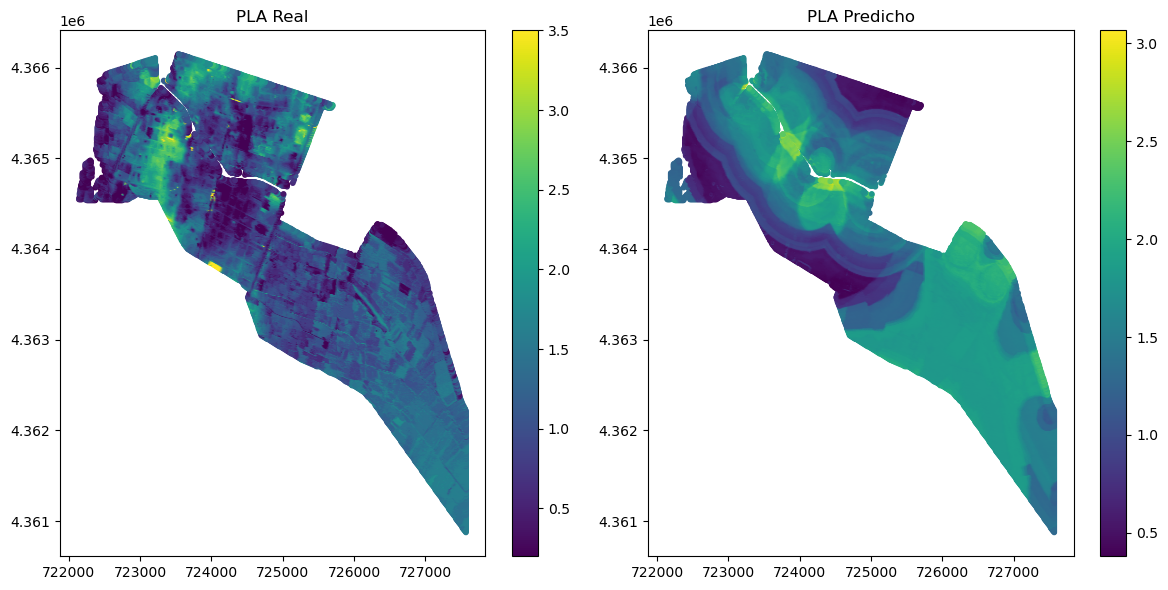

In [19]:
# =======================
# 4. Preparar X e y
# =======================
variables_modelo = ["A", "CIB", "CICCB", "DBB", "DOB", "P"]
X = df_final[variables_modelo]
y = df_final["PLA"]
coords = df_final[["POINT_X", "POINT_Y"]].copy()

# =======================
# 5. Escalar X
# =======================
X_full = pd.DataFrame(0, index=df_final.index,
                      columns=['PLA','A','CIB','CICCB','DBB','DOB','P'])
X_full[variables_modelo] = X
X_full['PLA'] = y
X_scaled = loaded_scaler.transform(X_full)
X_scaled = X_scaled[:, [1,2,3,4,5,6]]
y_scaled = X_scaled[:, 0]



# =======================
# 6. Predicciones con RF entrenado
# =======================
y_pred = modelo_rf_grid.predict(X_scaled)

min_pla = loaded_scaler.data_min_[0]
range_pla = loaded_scaler.data_range_[0]
y_pred_desn = y_pred * range_pla + min_pla


# Evaluación
r2 = r2_score(y, y_pred_desn)
mse = mean_squared_error(y, y_pred_desn)
rmse = np.sqrt(mse)

print(f"[Nuevos municipios] R²: {r2:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Mapa
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sc1 = axes[0].scatter(coords["POINT_X"], coords["POINT_Y"], c=y, cmap="viridis", s=10)
axes[0].set_title("PLA Real")
plt.colorbar(sc1, ax=axes[0])
sc2 = axes[1].scatter(coords["POINT_X"], coords["POINT_Y"], c=y_pred_desn, cmap="viridis", s=10)
axes[1].set_title("PLA Predicho")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()



In [17]:
print(X_full.describe())

                PLA             A           CIB         CICCB           DBB  \
count  96097.000000  96097.000000  96097.000000  96097.000000  96097.000000   
mean       1.147487      5.697125      0.296597      0.426828    653.698582   
std        0.524607      5.136170      0.134373      0.145239    390.114933   
min        0.200000      0.111615      0.102611      0.000172     12.175200   
25%        0.800000      0.781050      0.165648      0.305081    345.053986   
50%        1.161241      4.192370      0.283359      0.429409    621.177979   
75%        1.400000     10.286700      0.393824      0.526662    898.377014   
max        3.500000     17.535900      0.596594      0.999508   1794.939941   

                DOB             P  
count  96097.000000  96097.000000  
mean    1355.733474      0.671924  
std     1007.041687      1.021028  
min       24.745199      0.000000  
25%      566.789978      0.101132  
50%     1011.640015      0.346874  
75%     1948.550049      0.827396  


In [20]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelo_rf_grid, X_scaled, y, n_repeats=10, random_state=42)
importancia_local = pd.DataFrame({
    "variable": variables_modelo,
    "importancia": result.importances_mean
}).sort_values(by="importancia", ascending=False)

print(importancia_local)

C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


  variable  importancia
4      DOB     0.074192
2    CICCB     0.065090
0        A     0.009136
5        P     0.000704
3      DBB    -0.003834
1      CIB    -0.010691
